# Лабораторна робота. Комп'ютерний практикум 3

## Задача 1, варіант 2. Система:
$$\begin{cases} \dot{x} = -2x + 3y \\ \dot{y} = x - y \end{cases}$$

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from sympy import *

# Визначення системи
# x' = -2x + 3y
# y' = x - y
A = Matrix([[-2, 3], [1, -1]])
print("Матриця системи A:")
pprint(A)

Матриця системи A:
⎡-2  3 ⎤
⎢      ⎥
⎣1   -1⎦


## Крок 1. Знаходження власних чисел і власних векторів

In [9]:
lam = symbols('lambda')

# Характеристичне рівняння
char_poly = A.charpoly(lam)
print("Характеристичний поліном:")
pprint(char_poly.as_expr())

eigenvals = A.eigenvals()
print("\nВласні числа:")
for val, mult in eigenvals.items():
    print(f"  λ = {val}  (кратність {mult})")

eigenvects = A.eigenvects()
print("\nВласні вектори:")
for val, mult, vects in eigenvects:
    for v in vects:
        print(f"  λ = {val}: s = {v.T}")

Характеристичний поліном:
 2          
λ  + 3⋅λ - 1

Власні числа:
  λ = -sqrt(13)/2 - 3/2  (кратність 1)
  λ = -3/2 + sqrt(13)/2  (кратність 1)

Власні вектори:
  λ = -3/2 + sqrt(13)/2: s = Matrix([[-1/2 + sqrt(13)/2, 1]])
  λ = -sqrt(13)/2 - 3/2: s = Matrix([[-sqrt(13)/2 - 1/2, 1]])


## Крок 2. Визначення типу особливої точки

In [10]:
# Власні числа числово
evals = np.linalg.eigvals(np.array(A.tolist(), dtype=float))
evecs = np.linalg.eig(np.array(A.tolist(), dtype=float))[1]

lam1, lam2 = evals
print(f"λ₁ = {lam1:.6f}")
print(f"λ₂ = {lam2:.6f}")

print()
det_A = np.linalg.det(np.array(A.tolist(), dtype=float))
trace_A = np.trace(np.array(A.tolist(), dtype=float))
print(f"det(A) = {det_A:.4f}")
print(f"tr(A)  = {trace_A:.4f}")

if det_A != 0:
    if np.iscomplex(lam1) or np.iscomplex(lam2):
        alpha = np.real(lam1)
        if alpha == 0:
            print("\nТип особливої точки: ЦЕНТР")
        else:
            print("\nТип особливої точки: ФОКУС")
            print(f"  Дійсна частина α = {alpha:.4f} {'< 0 → траєкторії наближаються' if alpha < 0 else '> 0 → траєкторії віддаляються'}")
    else:
        lam1r, lam2r = np.real(lam1), np.real(lam2)
        if lam1r * lam2r < 0:
            print("\nТип особливої точки: СІДЛО")
        elif lam1r == lam2r:
            print("\nТип особливої точки: ВИРОДЖЕНИЙ або ДИКРИТИЧНИЙ ВУЗОЛ")
        else:
            direction = "від початку" if lam1r > 0 else "до початку"
            print(f"\nТип особливої точки: ВУЗОЛ (рух {direction} координат)")
            print(f"  λ₁·λ₂ = {lam1r*lam2r:.4f} > 0  ⟹  однаковий знак")

λ₁ = -3.302776
λ₂ = 0.302776

det(A) = -1.0000
tr(A)  = -3.0000

Тип особливої точки: СІДЛО


## Завдання 1. Кут перетину фазових траєкторій з прямою $y = x$

In [11]:
# На прямій y = x: підставляємо y = x у рівняння системи
# x' = -2x + 3x = x
# y' = x - x = 0
# Вектор фазової швидкості на прямій y=x: v = (x, 0)

# Дотична до траєкторії задається вектором (x', y') = (x, 0)
# Напрям прямої y = x задається вектором (1, 1)

# Кут між двома векторами a і b: cos θ = (a·b)/(|a||b|)

print("=" * 55)
print("Завдання 1. Кут перетину з прямою y = x")
print("=" * 55)
print()
print("На прямій y = x підставляємо y = x:")
print("  x' = -2x + 3x = x")
print("  y' = x - x  = 0")
print()
print("Вектор фазової швидкості: v = (x, 0), напрям: (1, 0) при x > 0")
print("Напрям прямої y = x:        u = (1, 1)")
print()

v = np.array([1, 0])  # напрям вектора швидкості (при x > 0)
u = np.array([1, 1])  # напрям прямої y = x

cos_theta = np.dot(v, u) / (np.linalg.norm(v) * np.linalg.norm(u))
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print(f"cos θ = (v · u)/(|v||u|) = {cos_theta:.6f}")
print(f"θ = arccos({cos_theta:.6f}) = {theta_rad:.6f} рад = {theta_deg:.4f}°")
print()
print(f"Відповідь: фазові траєкторії перетинають пряму y = x під кутом θ = 45°")

Завдання 1. Кут перетину з прямою y = x

На прямій y = x підставляємо y = x:
  x' = -2x + 3x = x
  y' = x - x  = 0

Вектор фазової швидкості: v = (x, 0), напрям: (1, 0) при x > 0
Напрям прямої y = x:        u = (1, 1)

cos θ = (v · u)/(|v||u|) = 0.707107
θ = arccos(0.707107) = 0.785398 рад = 45.0000°

Відповідь: фазові траєкторії перетинають пряму y = x під кутом θ = 45°


## Завдання 2. Кут примикання траєкторій до початку координат

In [12]:
print("=" * 60)
print("Завдання 2. Поведінка траєкторій поблизу точки (0,0)")
print("=" * 60)
print()

# Власні числа і вектори
A_num2 = np.array([[-2, 3], [1, -1]], dtype=float)
evals_num, evecs_num = np.linalg.eig(A_num2)

print("Власні числа та вектори (сепаратриси):")
for i in range(2):
    lv = evals_num[i]
    sv = evecs_num[:, i]
    angle = np.degrees(np.arctan2(sv[1], sv[0]))
    stability = 'стійка сепаратриса (λ < 0, рух ДО (0,0))' if lv < 0 else 'нестійка сепаратриса (λ > 0, рух ВІД (0,0))'
    print(f"  λ{i+1} = {lv:.4f},  s{i+1} = ({sv[0]:.4f}, {sv[1]:.4f}),  кут від Ox = {angle:.4f}°")
    print(f"    → {stability}")

print()
print("Тип особливої точки: СІДЛО")
print(f"  λ₁·λ₂ = {evals_num[0]*evals_num[1]:.4f} < 0  ⟹  власні числа різних знаків")
print()
print("Висновок щодо примикання:")
print("  Для СІДЛА більшість траєкторій НЕ ПРИМИКАЮТЬ до (0,0).")
print("  Вони огинають особливу точку, маючи форму гіпербол.")
print("  До (0,0) прямують ТІЛЬКИ траєкторії на стійких сепаратрисах")
print("  (напівпрямих вздовж вектора, що відповідає λ < 0).")
print()

# Стійка сепаратриса (λ < 0)
idx_neg = np.argmin(evals_num)  # індекс від'ємного λ
s_stable = evecs_num[:, idx_neg]
s_stable = s_stable / np.linalg.norm(s_stable)
angle_stable = np.degrees(np.arctan2(s_stable[1], s_stable[0]))
if angle_stable < 0:
    angle_stable += 180

print(f"Стійка сепаратриса: λ = {evals_num[idx_neg]:.4f}")
print(f"  Власний вектор: s = ({s_stable[0]:.4f}, {s_stable[1]:.4f})")
print(f"  Кут від осі Ox: {angle_stable:.4f}°")
print()
print("Аналітично (через sympy):")
for val, mult, vects in eigenvects:
    vx, vy = float(vects[0][0]), float(vects[0][1])
    ang = float(atan2(vy, vx) * 180 / pi)
    label = 'стійка' if float(val) < 0 else 'нестійка'
    print(f"  λ = {val}: s = {vects[0].T}  ({label} сепаратриса, кут = {ang:.4f}°)")

Завдання 2. Поведінка траєкторій поблизу точки (0,0)

Власні числа та вектори (сепаратриси):
  λ1 = -3.3028,  s1 = (-0.9172, 0.3983),  кут від Ox = 156.5267°
    → стійка сепаратриса (λ < 0, рух ДО (0,0))
  λ2 = 0.3028,  s2 = (-0.7933, -0.6089),  кут від Ox = -142.4904°
    → нестійка сепаратриса (λ > 0, рух ВІД (0,0))

Тип особливої точки: СІДЛО
  λ₁·λ₂ = -1.0000 < 0  ⟹  власні числа різних знаків

Висновок щодо примикання:
  Для СІДЛА більшість траєкторій НЕ ПРИМИКАЮТЬ до (0,0).
  Вони огинають особливу точку, маючи форму гіпербол.
  До (0,0) прямують ТІЛЬКИ траєкторії на стійких сепаратрисах
  (напівпрямих вздовж вектора, що відповідає λ < 0).

Стійка сепаратриса: λ = -3.3028
  Власний вектор: s = (-0.9172, 0.3983)
  Кут від осі Ox: 156.5267°

Аналітично (через sympy):
  λ = -3/2 + sqrt(13)/2: s = Matrix([[-1/2 + sqrt(13)/2, 1]])  (нестійка сепаратриса, кут = 37.5096°)
  λ = -sqrt(13)/2 - 3/2: s = Matrix([[-sqrt(13)/2 - 1/2, 1]])  (стійка сепаратриса, кут = 156.5267°)


## Завдання 3. Фазовий портрет системи

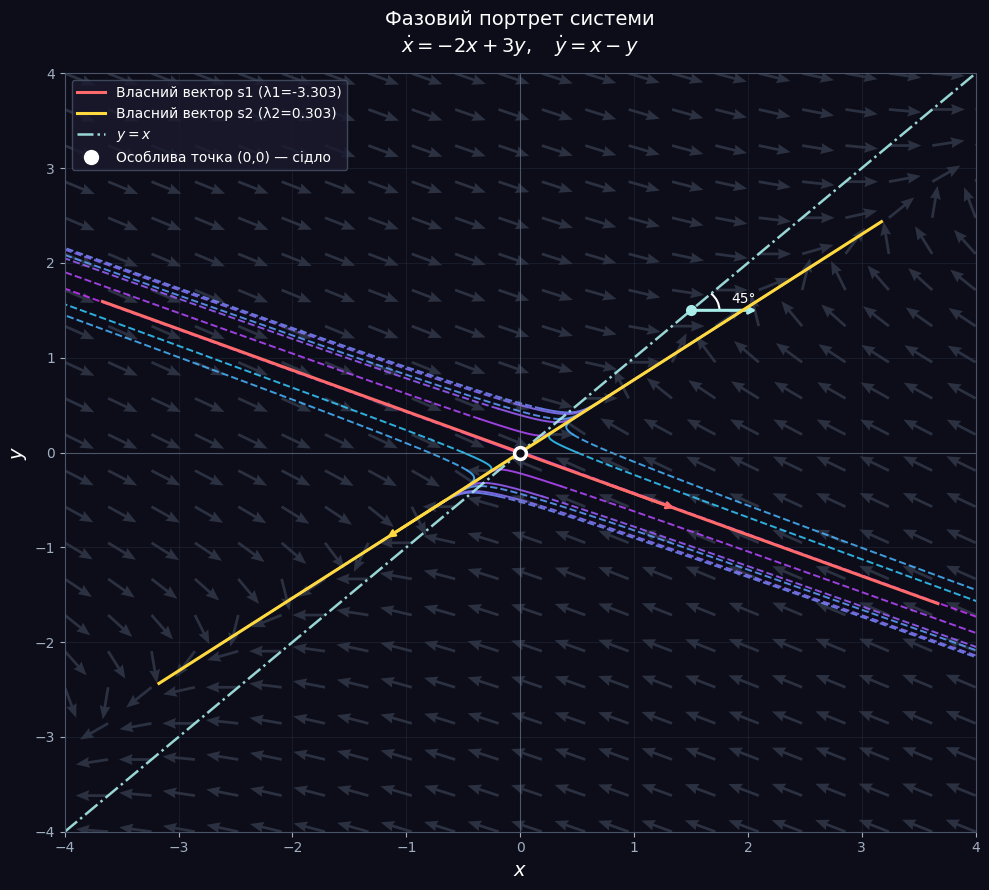

In [13]:
def system(t, state):
    x, y = state
    dxdt = -2*x + 3*y
    dydt = x - y
    return [dxdt, dydt]

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

# Сітка для поля напрямків
x_range = np.linspace(-4, 4, 22)
y_range = np.linspace(-4, 4, 22)
X, Y = np.meshgrid(x_range, y_range)
DX = -2*X + 3*Y
DY = X - Y
norm = np.sqrt(DX**2 + DY**2)
norm[norm == 0] = 1
ax.quiver(X, Y, DX/norm, DY/norm,
          color='#4a5568', alpha=0.5, scale=28, width=0.003,
          headwidth=4, headlength=5)

# Власні числа і вектори
A_num = np.array([[-2, 3], [1, -1]], dtype=float)
evals_n, evecs_n = np.linalg.eig(A_num)

# Кольори для траєкторій
colors_neg = plt.cm.cool(np.linspace(0.2, 0.8, 8))
colors_pos = plt.cm.autumn(np.linspace(0.2, 0.8, 8))

# Початкові умови навколо початку координат
angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
r = 0.5
t_span_fwd = (0, 6)
t_span_bwd = (0, -6)
t_eval_fwd = np.linspace(0, 6, 500)
t_eval_bwd = np.linspace(0, -6, 500)

for i, angle in enumerate(angles):
    x0 = r * np.cos(angle)
    y0 = r * np.sin(angle)
    
    # Інтегрування вперед (t > 0)
    sol_fwd = solve_ivp(system, t_span_fwd, [x0, y0],
                        t_eval=t_eval_fwd, max_step=0.01, dense_output=True)
    # Інтегрування назад (t < 0)
    sol_bwd = solve_ivp(system, t_span_bwd, [x0, y0],
                        t_eval=t_eval_bwd, max_step=0.01, dense_output=True)
    
    clr = colors_neg[i % 8]
    
    # Фільтруємо точки в межах графіка
    xf, yf = sol_fwd.y
    mask_f = (np.abs(xf) < 4.2) & (np.abs(yf) < 4.2)
    if mask_f.sum() > 1:
        ax.plot(xf[mask_f], yf[mask_f], color=clr, lw=1.4, alpha=0.85)
    
    xb, yb = sol_bwd.y
    mask_b = (np.abs(xb) < 4.2) & (np.abs(yb) < 4.2)
    if mask_b.sum() > 1:
        ax.plot(xb[mask_b], yb[mask_b], color=clr, lw=1.4, alpha=0.85, linestyle='--')

# Власні напрямки (напівпрямі вздовж власних векторів)
eigen_colors = ['#ff6b6b', '#ffd93d']
for i in range(2):
    lv = evals_n[i]
    sv = evecs_n[:, i]
    sv = sv / np.linalg.norm(sv)
    t_line = np.linspace(-4, 4, 200)
    xl = sv[0] * t_line
    yl = sv[1] * t_line
    mask = (np.abs(xl) < 4.2) & (np.abs(yl) < 4.2)
    ax.plot(xl[mask], yl[mask], color=eigen_colors[i], lw=2.2,
            label=f'Власний вектор s{i+1} (λ{i+1}={lv:.3f})', zorder=5)
    # Стрілки
    direction = 1 if lv > 0 else -1
    ax.annotate('', xy=(sv[0]*direction*1.5, sv[1]*direction*1.5),
                xytext=(sv[0]*direction*0.8, sv[1]*direction*0.8),
                arrowprops=dict(arrowstyle='->', color=eigen_colors[i], lw=2))

# Пряма y = x
x_line = np.linspace(-4, 4, 100)
ax.plot(x_line, x_line, color='#a8edea', lw=1.8, linestyle='-.', label='$y = x$', alpha=0.9)

# Виділяємо точку перетину (де траєкторія перетинає y=x)
# Показуємо вектор швидкості на прямій y=x у точці (1,1)
x_pt, y_pt = 1.5, 1.5
vx_pt = -2*x_pt + 3*y_pt  # = 1.5
vy_pt = x_pt - y_pt       # = 0
scale = 0.4
ax.annotate('', xy=(x_pt + vx_pt*scale, y_pt + vy_pt*scale),
            xytext=(x_pt, y_pt),
            arrowprops=dict(arrowstyle='->', color='#a8edea', lw=2.2))
ax.plot(x_pt, y_pt, 'o', color='#a8edea', ms=7, zorder=10)

# Кут 45° (дуга)
from matplotlib.patches import Arc
arc = Arc((x_pt, y_pt), 0.5, 0.5, angle=0, theta1=0, theta2=45,
          color='white', lw=1.5)
ax.add_patch(arc)
ax.text(x_pt + 0.35, y_pt + 0.08, '45°', color='white', fontsize=10)

# Особлива точка
ax.plot(0, 0, 'o', color='white', ms=10, zorder=10, label='Особлива точка (0,0) — сідло')
ax.plot(0, 0, 'o', color='#0d0d1a', ms=5, zorder=11)

# Осі
ax.axhline(0, color='#718096', lw=0.8, alpha=0.6)
ax.axvline(0, color='#718096', lw=0.8, alpha=0.6)

# Оформлення
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel('$x$', color='white', fontsize=14)
ax.set_ylabel('$y$', color='white', fontsize=14)
ax.set_title('Фазовий портрет системи\n'
             r'$\dot{x} = -2x + 3y,\quad \dot{y} = x - y$',
             color='white', fontsize=14, pad=15)
ax.tick_params(colors='#a0aec0')
for spine in ax.spines.values():
    spine.set_edgecolor('#4a5568')

legend = ax.legend(loc='upper left', facecolor='#1a1a2e', edgecolor='#4a5568',
                   labelcolor='white', fontsize=10)

ax.grid(True, color='#2d3748', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('Poshtak_lab_3_1.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()

## Підсумок

| Характеристика | Результат |
|---|---|
| Характеристичний поліном | $\lambda^2 + 3\lambda - 1 = 0$ |
| Власні числа | $\lambda_1 \approx 0.303 > 0$,  $\lambda_2 \approx -3.303 < 0$  (дійсні, **різних знаків**) |
| Тип особливої точки | **Сідло** ($\lambda_1 \cdot \lambda_2 < 0$) |
| Кут перетину з $y=x$ | **45°** (вектор швидкості $\mathbf{v}=(x,0) \parallel Ox$ на $y=x$) |
| Примикання до $(0,0)$ | Більшість траєкторій **не примикають** (огинають як гіперболи); до $(0,0)$ прямують лише стійкі сепаратриси ($\lambda_2 < 0$) |

In [14]:
print("=" * 55)
print("ПІДСУМОК")
print("=" * 55)

A_num = np.array([[-2, 3], [1, -1]], dtype=float)
evals_n, evecs_n = np.linalg.eig(A_num)
lam1, lam2 = sorted(evals_n)  # lam1 < 0, lam2 > 0

print(f"\n1) Характеристичний поліном: λ² + 3λ - 1 = 0")
print(f"   λ₁ = {evals_n[0]:.4f},  λ₂ = {evals_n[1]:.4f}")
print(f"   λ₁·λ₂ = {evals_n[0]*evals_n[1]:.4f} < 0  ⟹  власні числа РІЗНИХ знаків")
print(f"   ⟹  Особлива точка (0,0) — СІДЛО")

print(f"\n2) Кут перетину фазових траєкторій з прямою y = x:")
print(f"   На y = x підставляємо y = x:")
print(f"     x' = -2x + 3x = x,   y' = x - x = 0")
print(f"   Вектор швидкості v = (1, 0), напрям прямої u = (1, 1)")
print(f"   cos θ = (1·1 + 0·1)/(√1·√2) = 1/√2  ⟹  θ = 45°")

print(f"\n3) Поведінка траєкторій поблизу (0,0):")
print(f"   Тип СІДЛО ⟹ більшість траєкторій НЕ ПРИМИКАЮТЬ до (0,0).")
print(f"   Вони огинають точку, маючи форму гіпербол.")
idx_neg = np.argmin(evals_n)
s_st = evecs_n[:, idx_neg] / np.linalg.norm(evecs_n[:, idx_neg])
ang_st = np.degrees(np.arctan2(s_st[1], s_st[0]))
print(f"   Стійка сепаратриса (λ={evals_n[idx_neg]:.4f}): напрямок s=({s_st[0]:.4f},{s_st[1]:.4f}), кут={ang_st:.2f}°")
idx_pos = np.argmax(evals_n)
s_un = evecs_n[:, idx_pos] / np.linalg.norm(evecs_n[:, idx_pos])
ang_un = np.degrees(np.arctan2(s_un[1], s_un[0]))
print(f"   Нестійка сепаратриса (λ={evals_n[idx_pos]:.4f}): напрямок s=({s_un[0]:.4f},{s_un[1]:.4f}), кут={ang_un:.2f}°")

ПІДСУМОК

1) Характеристичний поліном: λ² + 3λ - 1 = 0
   λ₁ = -3.3028,  λ₂ = 0.3028
   λ₁·λ₂ = -1.0000 < 0  ⟹  власні числа РІЗНИХ знаків
   ⟹  Особлива точка (0,0) — СІДЛО

2) Кут перетину фазових траєкторій з прямою y = x:
   На y = x підставляємо y = x:
     x' = -2x + 3x = x,   y' = x - x = 0
   Вектор швидкості v = (1, 0), напрям прямої u = (1, 1)
   cos θ = (1·1 + 0·1)/(√1·√2) = 1/√2  ⟹  θ = 45°

3) Поведінка траєкторій поблизу (0,0):
   Тип СІДЛО ⟹ більшість траєкторій НЕ ПРИМИКАЮТЬ до (0,0).
   Вони огинають точку, маючи форму гіпербол.
   Стійка сепаратриса (λ=-3.3028): напрямок s=(-0.9172,0.3983), кут=156.53°
   Нестійка сепаратриса (λ=0.3028): напрямок s=(-0.7933,-0.6089), кут=-142.49°
